## Loading Met Office Deterministic Forecast data into Icechunk

The Met Office Deterministic collections have data for each variable and forecast time step stored in a separate NetCDF file. This makes querying the data somewhat cumbersome because you need to write a STAC search query then write the right incantation to load the assets of interest into an xarray Dataset. This is a perfect application for a virtual representation of the collection in Icechunk that can simply be 'opened' by xarray and queried using the `sel` and `isel` methods.

In this tutorial you will learn how to construct a virtual copy of the forecast hour zero records from the Met Office Global Deterministic collection and how to write it to a persistent icechunk store that could be used again later. At the end there is also a performance benchmark analysis that compares query performance for the icechunk store to the "legacy" approach involving STAC queries and more manual file i/o operations with `xarray`.

In [1]:
%pip install -q icechunk pystac-client xarray dask[distributed] obstore obspec-utils pystac tqdm virtualizarr h5py h5netcdf

/home/henry/workspace/microsoft/PlanetaryComputerExamples/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import time
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from contextlib import contextmanager
from dataclasses import dataclass
from datetime import UTC, datetime, timedelta
from itertools import batched
from typing import Any
from urllib.parse import urlparse

import icechunk as ic
import pandas as pd
import pystac_client
import xarray as xr
import zarr
from icechunk.credentials import AzureRefreshableCredential
from obspec_utils.readers import BlockStoreReader
from obspec_utils.registry import ObjectStoreRegistry
from obstore.auth.planetary_computer import PlanetaryComputerCredentialProvider
from obstore.store import AzureStore
from pystac import Collection, Item, ItemCollection
from tqdm import tqdm
from virtualizarr import open_virtual_mfdataset
from virtualizarr.parsers import HDFParser

zarr.config.set({"async.concurrency": 128})
pd.set_option("display.precision", 2)

STACType = dict[str, Any] | Item | ItemCollection | Collection

### Gather items in a STAC search

The Met Office STAC items have `https` asset hrefs which work fine for basic file reads but for the smoothest integration with obspec-utils and icechunk we need to convert them to `abfs://` hrefs.

See https://github.com/developmentseed/obspec-utils/issues/79 for a discussion on improving the handling of Azure Blob https links in obspec-utils.

The following functions can be used to apply this modification to the asset hrefs as they are processed by pystac-client.

In [3]:
def https_blob_to_abfs(url: str) -> tuple[str, str, str]:
    """Convert an Azure Blob HTTPS URL to an ABFS URL."""
    parsed = urlparse(url)
    if parsed.scheme != "https" or not parsed.netloc.endswith(".blob.core.windows.net"):
        raise ValueError(f"Expected an Azure Blob HTTPS URL, got {url!r}")

    account_name = parsed.netloc.split(".")[0]
    container, blob_path = parsed.path.lstrip("/").split("/", 1)
    return f"abfs://{container}/{blob_path}", account_name, container


def _rewrite_asset_dict_in_place(asset: dict[str, Any]) -> None:
    href = asset.get("href")
    if not isinstance(href, str):
        return

    parsed = urlparse(href)
    if parsed.scheme != "https" or not parsed.netloc.endswith(".blob.core.windows.net"):
        return

    abfs_href, _, _ = https_blob_to_abfs(href)
    alternate = asset.setdefault("alternate", {})
    if isinstance(alternate, dict):
        alternate.setdefault("https", {"href": href})
    asset["href"] = abfs_href


def _rewrite_item_dict_in_place(item: dict[str, Any]) -> None:
    assets = item.get("assets")
    if not isinstance(assets, dict):
        return

    for asset in assets.values():
        if isinstance(asset, dict):
            _rewrite_asset_dict_in_place(asset)


def _rewrite_item_in_place(item: Item) -> None:
    for asset in item.assets.values():
        href = asset.href
        parsed = urlparse(href)
        if parsed.scheme != "https" or not parsed.netloc.endswith(
            ".blob.core.windows.net"
        ):
            continue

        abfs_href, _, _ = https_blob_to_abfs(href)
        alternate = asset.extra_fields.setdefault("alternate", {})
        if isinstance(alternate, dict):
            alternate.setdefault("https", {"href": href})
        asset.href = abfs_href


def replace_https_with_abfs(obj: STACType) -> None:
    """Rewrite Azure Blob asset hrefs to ABFS in place for pystac-client."""
    if isinstance(obj, ItemCollection):
        for item in obj.items:
            _rewrite_item_in_place(item)
        return

    if isinstance(obj, Item):
        _rewrite_item_in_place(obj)
        return

    if not isinstance(obj, dict):
        return

    if obj.get("type") == "FeatureCollection":
        for feature in obj.get("features", []):
            if isinstance(feature, dict):
                _rewrite_item_dict_in_place(feature)
        return

    if obj.get("type") == "Feature":
        _rewrite_item_dict_in_place(obj)

Start by running a STAC search for a few days of historical Met Office zero-hour forecast (analysis) records from the Global Deterministic Near Surface collection (`met-office-global-deterministic-near-surface`). Each item contains a few dozen assets and each asset references a single NetCDF file with a single data variable. See the [comprehensive Met Office tutorial notebook](./met-office-forecast-data.ipynb) for a more complete description of the dataset's structure.

In [6]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=replace_https_with_abfs,
)

search = catalog.search(
    collections="met-office-global-deterministic-near-surface",
    datetime=[
        datetime(2026, 5, 1, tzinfo=UTC),
        datetime(2026, 6, 1, tzinfo=UTC) - timedelta(seconds=1),
    ],
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:horizon"},
            "PT0000H00M",
        ],
    },
    sortby="datetime",
    limit=100,
)

items = search.item_collection()

print(f"found {len(items)} items")

sample_item = items[0]
print(
    f"assets for {sample_item.datetime.isoformat()}:",
    list(sample_item.assets.keys()),
)

sample_asset = sample_item.assets["temperature_at_surface"]
sample_asset

found 124 items
assets for 2026-05-01T00:00:00+00:00: ['rainfall_rate', 'snowfall_rate', 'wind_gust_at_10m', 'wind_speed_at_10m', 'precipitation_rate', 'height_of_orography', 'wind_direction_at_10m', 'temperature_at_surface', 'pressure_at_mean_sea_level', 'visibility_at_screen_level', 'snow_depth_water_equivalent', 'temperature_at_screen_level', 'fog_fraction_at_screen_level', 'rainfall_rate_from_convection', 'snowfall_rate_from_convection', 'relative_humidity_at_screen_level', 'radiation_flux_in_uv_downward_at_surface', 'temperature_of_dew_point_at_screen_level', 'radiation_flux_in_longwave_downward_at_surface', 'radiation_flux_in_shortwave_total_downward_at_surface', 'radiation_flux_in_shortwave_direct_downward_at_surface']


<Asset href=abfs://deterministic/global/near-surface/20260501T0000Z/20260501T0000Z-PT0000H00M-temperature_at_surface.nc>

### Configure cloud storage access for VirtualiZarr

Now use a sample asset to configure object storage access for reading the raw data. 

The `PlanetaryComputerCredentialProvider` from obstore can be used to automatically generate SAS tokens for individual asset read operations.

In [7]:
sample_asset_https_href = sample_asset.extra_fields["alternate"]["https"]["href"]
_, account_name, container_name = https_blob_to_abfs(sample_asset_https_href)

pc_credential_provider = PlanetaryComputerCredentialProvider(
    f"abfs://{container_name}",
    account_name=account_name,
)

base_store = AzureStore(
    container_name=container_name,
    account_name=account_name,
    credential_provider=pc_credential_provider,
)

Set up the object storage registry for virtualizarr and define a `ThreadPoolExecutor` to handle parallelism while virtualizing the assets.

In [8]:
parser = HDFParser(reader_factory=BlockStoreReader)

registry = ObjectStoreRegistry({f"abfs://{container_name}": base_store})


class VirtualizarrThreadPool(ThreadPoolExecutor):
    def __init__(self):
        super().__init__(max_workers=32)

Now open the assets for a single item as a virtual dataset. Each asset contains one data variable (and several other non-data variables). We are doing this so we can inspect the structure of the virtual representation.

In [9]:
%%time
t0 = open_virtual_mfdataset(
    urls=[asset.href for asset in items[0].assets.values()],
    parser=parser,
    registry=registry,
    combine="nested",
    parallel=VirtualizarrThreadPool,
    compat="override",
    join="override",
    coords="minimal",
    loadable_variables=["time"],
).expand_dims(["time"])
t0

CPU times: user 1 s, sys: 603 ms, total: 1.61 s
Wall time: 22.9 s


<xarray.Dataset> Size: 413MB
Dimensions:                                           (time: 1, latitude: 1920,
                                                       longitude: 2560, bnds: 2)
Coordinates:
  * time                                              (time) datetime64[ns] 8B ...
    latitude                                          (latitude) float32 8kB ...
    longitude                                         (longitude) float32 10kB ManifestArray<shape=(2560,), dtype=float32, chunks=(2560,...
    forecast_period                                   int32 4B ManifestArray<...
    forecast_reference_time                           int64 8B ManifestArray<...
    height                                            float32 4B ManifestArra...
Dimensions without coordinates: bnds
Data variables: (12/24)
    rainfall_rate                                     (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    latitude_longitude                                (time) int32 4B Manifes...
    latitude_bnds                                     (time, latitude, bnds) float32 15kB ManifestArray<shape=(1, 1920, 2), dtype=float32, chunks=...
    longitude_bnds                                    (time, longitude, bnds) float32 20kB ManifestArray<shape=(1, 2560, 2), dtype=float32, chunks...
    lwe_snowfall_rate                                 (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    wind_speed_of_gust                                (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    ...                                                ...
    relative_humidity                                 (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    surface_downwelling_ultraviolet_flux_in_air       (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    dew_point_temperature                             (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    surface_downwelling_longwave_flux_in_air          (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    surface_downwelling_shortwave_flux_in_air         (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
    surface_direct_downwelling_shortwave_flux_in_air  (time, latitude, longitude) float32 20MB ManifestArray<shape=(1, 1920, 2560), dtype=float32, chu...
Attributes:
    history:                      2026-05-01T03:21:10Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT168H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

### Set up an Icechunk repository
Prepare a local Icechunk repository. The `get_credentials` function will get pickled and stored in the icechunk repo so that clients know how to authenticate requests to the raw data.

You could also write the icechunk repo to an Azure Blob storage container to make it durable.

In [10]:
storage = ic.local_filesystem_storage(path="/tmp/metoffice-deterministic-global-local")
config = ic.config.RepositoryConfig.default()

config.set_virtual_chunk_container(
    ic.virtual.VirtualChunkContainer(
        f"abfs://{container_name}/", ic.storage.azure_store(account=account_name)
    )
)


def get_credentials():
    """Use obstore's PlanetaryComputerCredentialProvider to retrieve SAS token"""
    creds = pc_credential_provider()
    return AzureRefreshableCredential.SasToken(
        creds["sas_token"],
        creds["expires_at"],
    )


credentials = ic.credentials.containers_credentials(
    {
        f"abfs://{container_name}/": ic.credentials.azure_refreshable_credentials(
            get_credentials=get_credentials,
        )
    }
)
repo = ic.Repository.open_or_create(storage, config, credentials)

  2026-06-18T17:57:25.789646Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



### Write data to the Icechunk repository

Now iterate through batches of STAC items and load them into virtual arrays that can be written to the icechunk repo. The most efficient way to load the virtual arrays is to set up a nested set of hrefs. The nested list will merge the matching assets across items to construct time-aware cubes for each variable, then merge all variables into a single dataset. 

In [11]:
batches = list(batched(items, 31))

for i, batch in enumerate(tqdm(batches)):
    hrefs = defaultdict(list)
    for item in batch:
        for key, asset in item.assets.items():
            hrefs[key].append(asset.href)

    nested_urls = list(hrefs.values())

    vds = open_virtual_mfdataset(
        nested_urls,
        parser=parser,
        registry=registry,
        combine="nested",
        concat_dim=[None, "time"],  # concat across items, merge assets within each item
        parallel=VirtualizarrThreadPool,
        loadable_variables=["time"],
        coords="minimal",
        compat="override",
        join="override",
    )

    with repo.transaction(
        "main", message=f"Ingest data for {len(batch)} items"
    ) as store:
        vds.vz.to_icechunk(store, append_dim="time" if i > 0 else None)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [42:59<00:00, 644.82s/it]


### Read from the Icechunk repository

You can open a connection to the virtual array with a month's worth of forecast hour zero with xarray! 

In [12]:
repo = ic.Repository.open(storage, config, credentials)
session = repo.readonly_session("main")

ds = xr.open_zarr(session.store, zarr_format=3, consolidated=False, chunks=None)
ds

<xarray.Dataset> Size: 51GB
Dimensions:                                           (time: 124,
                                                       latitude: 1920,
                                                       longitude: 2560, bnds: 2)
Coordinates:
  * time                                              (time) datetime64[ns] 992B ...
  * latitude                                          (latitude) float32 8kB ...
  * longitude                                         (longitude) float32 10kB ...
    forecast_period                                   int32 4B ...
    height                                            float32 4B ...
    forecast_reference_time                           datetime64[ns] 8B ...
Dimensions without coordinates: bnds
Data variables: (12/24)
    air_pressure_at_sea_level                         (time, latitude, longitude) float32 2GB ...
    lwe_snowfall_rate                                 (time, latitude, longitude) float32 2GB ...
    relative_humidity                                 (time, latitude, longitude) float32 2GB ...
    dew_point_temperature                             (time, latitude, longitude) float32 2GB ...
    convective_rainfall_rate                          (time, latitude, longitude) float32 2GB ...
    longitude_bnds                                    (time, longitude, bnds) float32 3MB ...
    ...                                                ...
    wind_from_direction                               (time, latitude, longitude) float32 2GB ...
    latitude_longitude                                (time) int32 496B ...
    latitude_bnds                                     (time, latitude, bnds) float32 2MB ...
    rainfall_rate                                     (time, latitude, longitude) float32 2GB ...
    surface_temperature                               (time, latitude, longitude) float32 2GB ...
    fog_area_fraction                                 (time, latitude, longitude) float32 2GB ...
Attributes:
    history:                      2026-05-24T09:21:22Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT69H
    mosg__grid_domain:            global
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    gl_det
    source:                       Met Office Unified Model
    title:                        Global Model Forecast on Global 10 km Stand...
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

Then you can perform spatial or temporal queries using the xarray API.

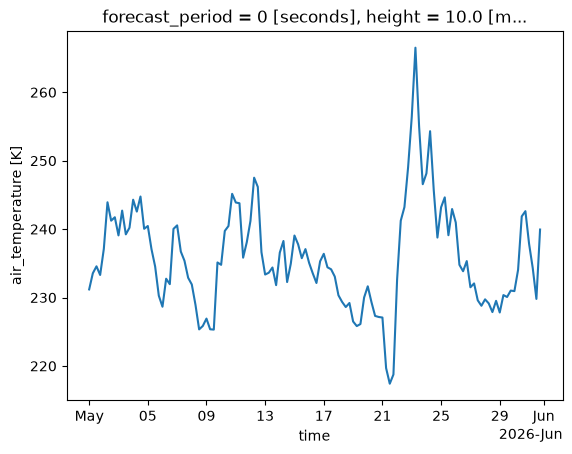

In [13]:
ds["air_temperature"].isel(longitude=100, latitude=100).plot()

### Legacy format versus Icechunk query comparisons

With the virtual array written to Icechunk we can compare a few common query patterns against the legacy workflow. For the legacy path we re-run a STAC search for the same `PT0000H00M` global near-surface records, but now the temporal constraint is pushed down into the STAC query so the legacy path only opens the raw NetCDF assets needed for each comparison.

The examples below time four representative access patterns for `air_temperature`: a time slice, a single point, a spatial slice, and a full-array load. To keep the comparison aligned across both approaches, each query uses `sel` with actual timestamp values rather than `isel` along the time dimension where appropriate.

In [19]:
@dataclass
class Timing:
    label: str
    seconds: float | None = None


LEGACY_ASSET_KEY = "temperature_at_screen_level"
DATA_VARIABLE = "air_temperature"


time_slice_start = pd.Timestamp(ds.time.isel(time=10).values)
time_slice_end = pd.Timestamp(ds.time.isel(time=45).values)
single_time = pd.Timestamp(ds.time.isel(time=60).values)
full_time_start = pd.Timestamp(ds.time.min().values)
full_time_end = pd.Timestamp(ds.time.max().values)


@contextmanager
def timer(label="Task"):
    """Time a block and expose the elapsed seconds after it exits."""
    timing = Timing(label=label)
    t0 = time.perf_counter()
    try:
        yield timing
    finally:
        timing.seconds = time.perf_counter() - t0


def to_stac_datetime(value):
    """Convert a timestamp-like value to an RFC3339 UTC string for STAC."""
    return pd.Timestamp(value).tz_localize("UTC").isoformat().replace("+00:00", "Z")


@contextmanager
def open_icechunk():
    """Open the local Icechunk repository as an xarray dataset."""
    setup_timings = {}

    with timer("icechunk: Repository.open") as t:
        repo = ic.Repository.open(storage, config, credentials)

    setup_timings["repository_open_seconds"] = t.seconds
    with timer("icechunk: readonly_session") as t:
        session = repo.readonly_session("main")

    setup_timings["readonly_session_seconds"] = t.seconds
    with timer("icechunk: xr.open_zarr") as t:
        dataset = xr.open_zarr(
            session.store, zarr_format=3, consolidated=False, chunks=None
        )

    setup_timings["open_dataset_seconds"] = t.seconds
    setup_timings["setup_seconds"] = sum(setup_timings.values())
    dataset.attrs["benchmark_setup_timings"] = setup_timings

    try:
        yield dataset
    finally:
        dataset.close()
        if hasattr(session, "close"):
            session.close()


@contextmanager
def open_legacy(datetime_query):
    """Open the legacy NetCDF assets matched by a targeted STAC query."""
    setup_timings = {}
    with timer(f"legacy: STAC item retrieval ({datetime_query})") as t:
        legacy_search = catalog.search(
            collections="met-office-global-deterministic-near-surface",
            datetime=datetime_query,
            filter_lang="cql2-json",
            filter={
                "op": "=",
                "args": [
                    {"property": "forecast:horizon"},
                    "PT0000H00M",
                ],
            },
            sortby="datetime",
            limit=100,
        )
        legacy_items = legacy_search.item_collection()

    setup_timings["stac_item_retrieval_seconds"] = t.seconds

    with timer("legacy: collect asset paths") as t:
        asset_paths = [
            urlparse(item.assets[LEGACY_ASSET_KEY].href).path.lstrip("/")
            for item in legacy_items
            if LEGACY_ASSET_KEY in item.assets
        ]

    setup_timings["collect_asset_paths_seconds"] = t.seconds

    with timer("legacy: xr.open_mfdataset") as t:
        dataset = xr.open_mfdataset(
            [BlockStoreReader(base_store, path) for path in asset_paths],
            engine="h5netcdf",
            chunks=None,
            decode_times=True,
            decode_timedelta=True,
            concat_dim="time",
            combine="nested",
            parallel=False,
            coords="minimal",
            compat="override",
        )

    setup_timings["open_dataset_seconds"] = t.seconds
    setup_timings["setup_seconds"] = sum(setup_timings.values())
    dataset.attrs["benchmark_setup_timings"] = setup_timings

    try:
        yield dataset
    finally:
        dataset.close()

In [ ]:
results = []

with timer("icechunk time slice") as total_t:
    with open_icechunk() as icechunk_ds:
        setup_seconds = icechunk_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("icechunk: load time slice") as load_t:
            icechunk_ds[DATA_VARIABLE].sel(
                time=slice(time_slice_start, time_slice_end)
            ).load()

results.append(
    {
        "query": "time slice",
        "backend": "icechunk",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("legacy time slice") as total_t:
    with open_legacy(
        f"{to_stac_datetime(time_slice_start)}/{to_stac_datetime(time_slice_end)}"
    ) as legacy_ds:
        setup_seconds = legacy_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("legacy: load time slice") as load_t:
            legacy_ds[DATA_VARIABLE].sel(
                time=slice(time_slice_start, time_slice_end)
            ).load()

results.append(
    {
        "query": "time slice",
        "backend": "legacy-stac-plus-netcdf",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("icechunk random point") as total_t:
    with open_icechunk() as icechunk_ds:
        setup_seconds = icechunk_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("icechunk: load random point") as load_t:
            icechunk_ds[DATA_VARIABLE].sel(
                time=slice(time_slice_start, time_slice_end)
            ).isel(
                latitude=187,
                longitude=241,
            ).load()

results.append(
    {
        "query": "random point",
        "backend": "icechunk",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("legacy random point") as total_t:
    with open_legacy(to_stac_datetime(single_time)) as legacy_ds:
        setup_seconds = legacy_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("legacy: load random point") as load_t:
            legacy_ds[DATA_VARIABLE].sel(
                time=slice(time_slice_start, time_slice_end)
            ).isel(
                latitude=187,
                longitude=241,
            ).load()

results.append(
    {
        "query": "random point",
        "backend": "legacy-stac-plus-netcdf",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("icechunk spatial slice") as total_t:
    with open_icechunk() as icechunk_ds:
        setup_seconds = icechunk_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("icechunk: load spatial slice") as load_t:
            icechunk_ds[DATA_VARIABLE].sel(time=single_time).isel(
                latitude=slice(150, 406),
                longitude=slice(200, 456),
            ).load()

results.append(
    {
        "query": "spatial slice",
        "backend": "icechunk",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("legacy spatial slice") as total_t:
    with open_legacy(to_stac_datetime(single_time)) as legacy_ds:
        setup_seconds = legacy_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("legacy: load spatial slice") as load_t:
            legacy_ds[DATA_VARIABLE].sel(time=single_time).isel(
                latitude=slice(150, 406),
                longitude=slice(200, 456),
            ).load()

results.append(
    {
        "query": "spatial slice",
        "backend": "legacy-stac-plus-netcdf",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("icechunk full array") as total_t:
    with open_icechunk() as icechunk_ds:
        setup_seconds = icechunk_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("icechunk: load full array") as load_t:
            icechunk_ds[DATA_VARIABLE].load()

results.append(
    {
        "query": "full array",
        "backend": "icechunk",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

with timer("legacy full array") as total_t:
    with open_legacy(
        f"{to_stac_datetime(full_time_start)}/{to_stac_datetime(full_time_end)}"
    ) as legacy_ds:
        setup_seconds = legacy_ds.attrs["benchmark_setup_timings"]["setup_seconds"]
        with timer("legacy: load full array") as load_t:
            legacy_ds[DATA_VARIABLE].load()

results.append(
    {
        "query": "full array",
        "backend": "legacy-stac-plus-netcdf",
        "setup_seconds": setup_seconds,
        "load_seconds": load_t.seconds,
        "total_seconds": total_t.seconds,
    }
)

In [23]:
comparison_df = pd.DataFrame(results).set_index(["query", "backend"]).sort_index()
comparison_df

setup_seconds  load_seconds  \
query         backend                                                
full array    icechunk                          1.42        105.97   
              legacy-stac-plus-netcdf          76.19        189.01   
random point  icechunk                          1.89          1.12   
              legacy-stac-plus-netcdf           0.99          0.18   
spatial slice icechunk                          1.37          0.85   
              legacy-stac-plus-netcdf           1.12          0.20   
time slice    icechunk                          1.67         32.67   
              legacy-stac-plus-netcdf          21.33         50.89   

                                       total_seconds  
query         backend                                 
full array    icechunk                        107.39  
              legacy-stac-plus-netcdf         265.24  
random point  icechunk                          3.01  
              legacy-stac-plus-netcdf           1.17  
spatial slice icechunk                          2.23  
              legacy-stac-plus-netcdf           1.33  
time slice    icechunk                         34.35  
              legacy-stac-plus-netcdf          72.34

This analysis shows that highly targeted queries for small spatial and/or temporal windows can be performed very quickly with the legacy approach, but as the number of files required by a given query increases Icechunk will be much more performant! The Icechunk approach has a fixed overhead cost of the 'setup' step (opening the zarr array) that is higher than the setup cost of the legacy approach for targeted queries but for queries that involve more time steps the legacy setup cost is much higher.